# Conversion Rate -- Prédiction du taux de conversion

Problématique : comment prédire si un visiteur va convertir (achat, inscription) à partir de ses caractéristiques démographiques et comportementales ?

Approche :
1. EDA et nettoyage des données (valeurs aberrantes)
2. Analyse du déséquilibre des classes
3. Modélisation : Régression Logistique, Random Forest, XGBoost
4. Optimisation des hyperparamètres par GridSearchCV
5. Feature Importance et recommandations business

Métrique principale : F1-Score (classe 1) en raison du déséquilibre des classes.

## 1. Analyse exploratoire et préparation des données

Importation des librairies et chargement du dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

# Configuration de l'affichage
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
warnings.filterwarnings("ignore")

### 1.1 Chargement du dataset

Chargement du fichier d'entraînement depuis le dossier `data/raw`.

In [2]:
# Chargement du dataset d'entrainement
df = pd.read_csv("../data/raw/conversion_data_train.csv")

print(
    f"Dimensions du dataset : {df.shape[0]} lignes, "
    f"{df.shape[1]} colonnes."
)
display(df.head())

Dimensions du dataset : 284580 lignes, 6 colonnes.


,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


### 1.2 Audit des données

Vérification des types, valeurs nulles et anomalies.

In [3]:
# Verification des types et des valeurs nulles
df.info()

print("-" * 30)
print("Pourcentage de valeurs manquantes par colonne :")
print(df.isnull().mean() * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              284580 non-null  object
 1   age                  284580 non-null  int64 
 2   new_user             284580 non-null  int64 
 3   source               284580 non-null  object
 4   total_pages_visited  284580 non-null  int64 
 5   converted            284580 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 13.0+ MB
------------------------------
Pourcentage de valeurs manquantes par colonne :
country                0.0
age                    0.0
new_user               0.0
source                 0.0
total_pages_visited    0.0
converted              0.0
dtype: float64


In [4]:
# Statistiques descriptives
# Detection des anomalies (ex : age negatif ou > 100)
df.describe()

,age,new_user,total_pages_visited,converted
count,284580.000000,284580.000000,284580.000000,284580.000000
mean,30.564203,0.685452,4.873252,0.032258
std,8.266789,0.464336,3.341995,0.176685
min,17.000000,0.000000,1.000000,0.000000
25%,24.000000,0.000000,2.000000,0.000000
50%,30.000000,1.000000,4.000000,0.000000
75%,36.000000,1.000000,7.000000,0.000000
max,123.000000,1.000000,29.000000,1.000000


### 1.3 Analyse de la variable cible

Distribution de `converted`. Le déséquilibre des classes impose d'utiliser le F1-Score plutôt que l'Accuracy.

Taux de non-conversion (0) : 96.77%
Taux de conversion (1)     : 3.23%


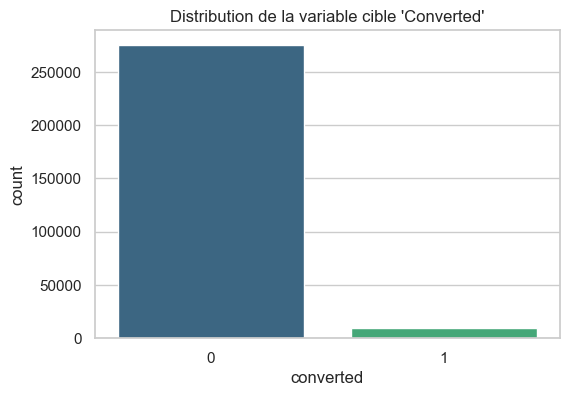

In [5]:
# Distribution de la variable cible
conversion_rate = (
    df["converted"].value_counts(normalize=True) * 100
)

print(
    f"Taux de non-conversion (0) : "
    f"{conversion_rate[0]:.2f}%"
)
print(
    f"Taux de conversion (1)     : "
    f"{conversion_rate[1]:.2f}%"
)

plt.figure(figsize=(6, 4))
sns.countplot(
    x="converted", hue="converted",
    legend=False, data=df, palette="viridis"
)
plt.title(
    "Distribution de la variable cible 'Converted'"
)
plt.show()

### 1.4 Analyse des corrélations et comportements

Taux de conversion par pays et par source de trafic.

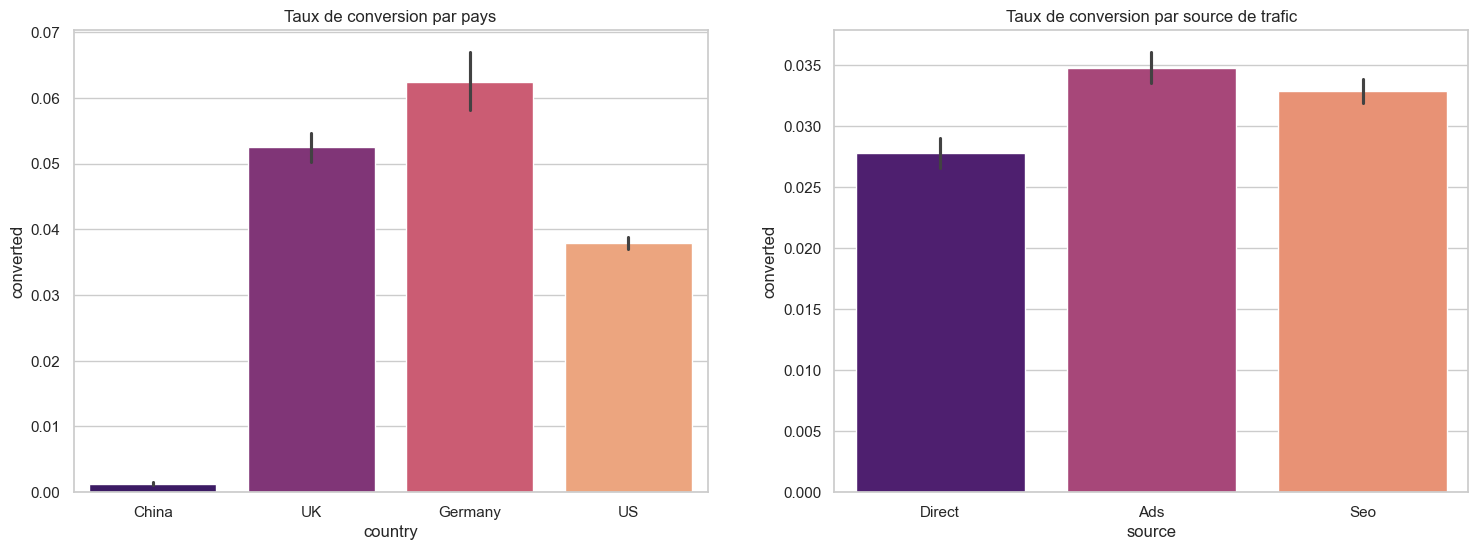

In [6]:
# Taux de conversion par pays et par source
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    x="country", y="converted", hue="country",
    legend=False, data=df, ax=axes[0], palette="magma"
)
axes[0].set_title("Taux de conversion par pays")

sns.barplot(
    x="source", y="converted", hue="source",
    legend=False, data=df, ax=axes[1], palette="magma"
)
axes[1].set_title(
    "Taux de conversion par source de trafic"
)

plt.show()

Disparités de conversion selon les pays (China et US plus élevés). La source de trafic a un impact limité sur le taux de conversion.

Distribution de l'âge et impact du nombre de pages visitées sur la conversion.

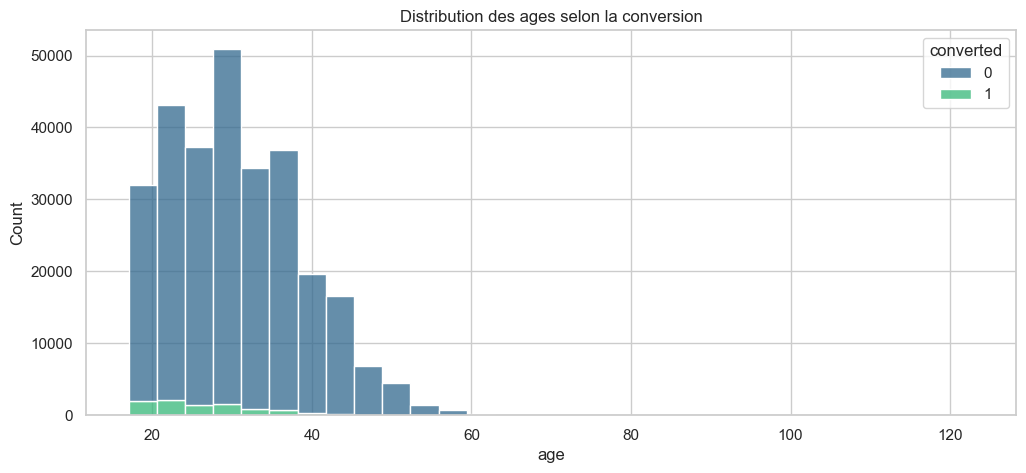

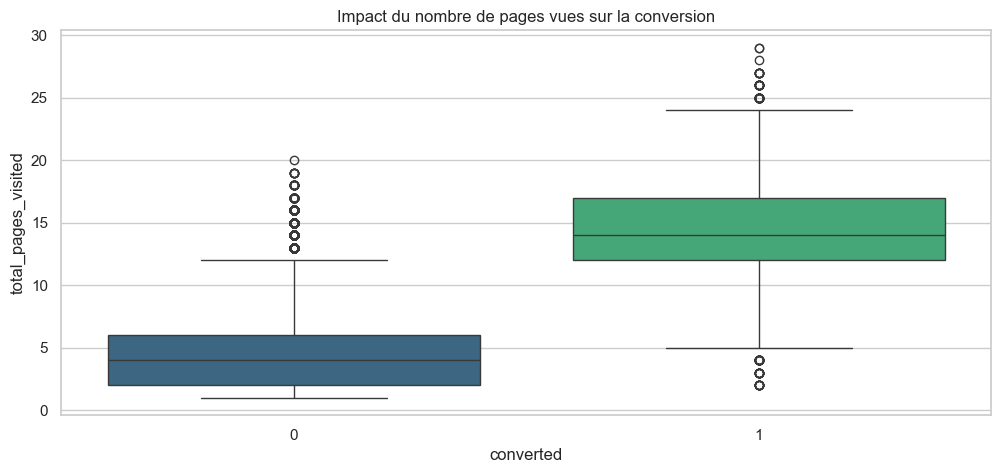

In [7]:
# Distribution des ages selon la conversion
plt.figure(figsize=(12, 5))
sns.histplot(
    data=df, x="age", hue="converted",
    multiple="stack", bins=30, palette="viridis"
)
plt.title("Distribution des ages selon la conversion")
plt.show()

# Impact du nombre de pages visitees
plt.figure(figsize=(12, 5))
sns.boxplot(
    x="converted", y="total_pages_visited",
    hue="converted", legend=False,
    data=df, palette="viridis"
)
plt.title(
    "Impact du nombre de pages vues sur la conversion"
)
plt.show()

### 1.5 Nettoyage des données

Suppression des valeurs aberrantes : âge max = 123 ans (probablement des erreurs de saisie).

In [8]:
# Suppression des ages aberrants (> 100 ans)
print(f"Lignes avant nettoyage : {len(df)}")
df = df[df["age"] < 100]
print(f"Lignes apres nettoyage : {len(df)}")

Lignes avant nettoyage : 284580
Lignes apres nettoyage : 284578


### 1.6 Synthèse de l'EDA

Le dataset est fortement déséquilibré : environ 97 % de non-conversions vs 3 % de conversions. L'Accuracy serait trompeuse, le F1-Score est la métrique adaptée.

Le nombre de pages visitées (`total_pages_visited`) est le prédicteur le plus discriminant : les visiteurs qui consultent plus de 12-15 pages convertissent quasi systématiquement. Les jeunes (18-30 ans) convertissent légèrement mieux que les tranches plus âgées. Les disparités géographiques existent mais restent modérées. Aucune valeur manquante, seulement 2 lignes avec un âge aberrant (> 100 ans) supprimées.

## 2. Modélisation

### 2.1 Preprocessing

- One-Hot Encoding des variables catégorielles (`country`, `source`).
- Split Train/Test stratifié 80/20.
- StandardScaler pour la normalisation.

In [9]:
# Separation target / features
target_name = "converted"
X = df.drop(target_name, axis=1)
y = df[target_name]

# One-Hot Encoding des variables categorielles
X = pd.get_dummies(X, drop_first=True)

# Split train/test stratifie (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation (fit sur train uniquement)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(
    f"Train : {X_train_scaled.shape}, "
    f"Test : {X_test_scaled.shape}"
)

Train : (227662, 8), Test : (56916, 8)


### 2.2 Baseline : Régression Logistique

Premier modèle simple avec `class_weight='balanced'` pour compenser le déséquilibre des classes.

Classification Report (Baseline) :
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     55080
           1       0.35      0.94      0.51      1836

    accuracy                           0.94     56916
   macro avg       0.67      0.94      0.74     56916
weighted avg       0.98      0.94      0.95     56916



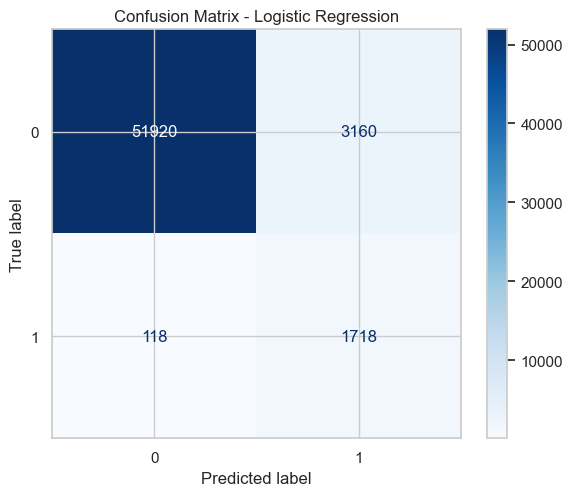


F1-Score (classe 1) : 0.5118


In [10]:
# Regression Logistique (baseline)
model_lr = LogisticRegression(
    class_weight="balanced", random_state=42
)
model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)

print("Classification Report (Baseline) :")
print(classification_report(y_test, y_pred_lr))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, ax=ax, cmap="Blues"
)
ax.set_title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

print(
    f"\nF1-Score (classe 1) : "
    f"{f1_score(y_test, y_pred_lr):.4f}"
)

La régression logistique avec pondération des classes obtient un F1-Score d'environ 0.51 pour la classe 1. C'est un point de départ acceptable mais insuffisant : le modèle linéaire ne capture pas bien les interactions non linéaires entre les features. Les modèles ensemblistes devraient améliorer significativement ce résultat.

### 2.3 Random Forest

Ensemble d'arbres de décision par bagging. `class_weight='balanced'` pour gérer le déséquilibre.

Classification Report (Random Forest) :
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     55080
           1       0.44      0.83      0.58      1836

    accuracy                           0.96     56916
   macro avg       0.72      0.90      0.78     56916
weighted avg       0.98      0.96      0.97     56916



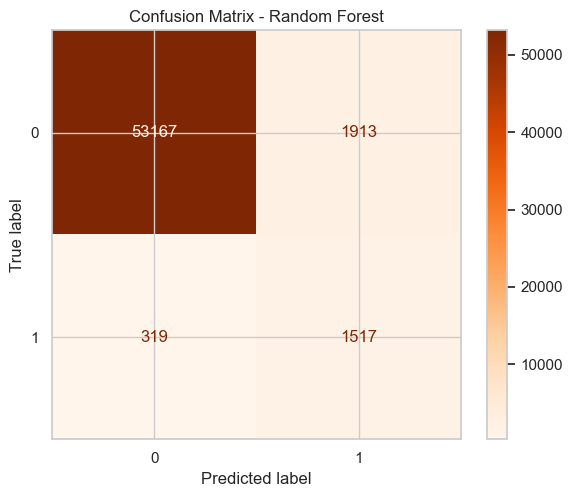


F1-Score (classe 1) : 0.5761


In [11]:
# Random Forest avec ponderation des classes
model_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
model_rf.fit(X_train_scaled, y_train)

y_pred_rf = model_rf.predict(X_test_scaled)

print("Classification Report (Random Forest) :")
print(classification_report(y_test, y_pred_rf))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, ax=ax, cmap="Oranges"
)
ax.set_title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

print(
    f"\nF1-Score (classe 1) : "
    f"{f1_score(y_test, y_pred_rf):.4f}"
)

Le Random Forest améliore le F1-Score à environ 0.58, un gain notable par rapport à la baseline. Cependant, le modèle reste en dessous de 0.60, ce qui laisse penser qu'un modèle de boosting pourrait mieux capturer les patterns de conversion.

### 2.4 XGBoost

Gradient boosting, particulièrement performant sur les données tabulaires.

Classification Report (XGBoost) :
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     55080
           1       0.85      0.68      0.75      1836

    accuracy                           0.99     56916
   macro avg       0.92      0.84      0.87     56916
weighted avg       0.98      0.99      0.98     56916



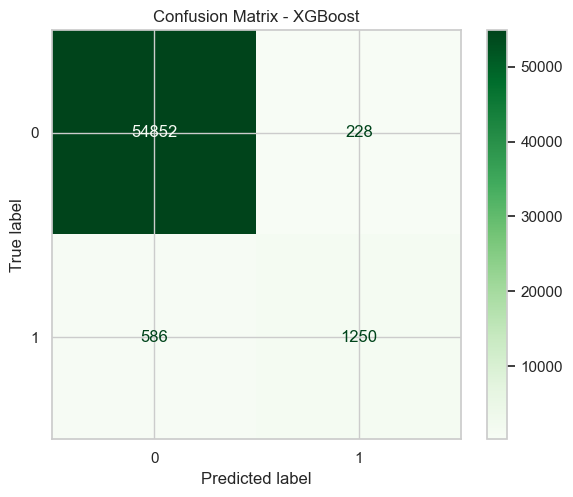


F1-Score (classe 1) : 0.7544


In [12]:
# XGBoost avec parametres par defaut
model_xgb = XGBClassifier(random_state=42)
model_xgb.fit(X_train_scaled, y_train)

y_pred_xgb = model_xgb.predict(X_test_scaled)

print("Classification Report (XGBoost) :")
print(classification_report(y_test, y_pred_xgb))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb, ax=ax, cmap="Greens"
)
ax.set_title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.show()

print(
    f"\nF1-Score (classe 1) : "
    f"{f1_score(y_test, y_pred_xgb):.4f}"
)

XGBoost avec les paramètres par défaut atteint un F1-Score d'environ 0.75, une amélioration considérable par rapport aux modèles précédents. Le gradient boosting capture mieux les interactions non linéaires entre les features. L'optimisation des hyperparamètres devrait encore améliorer ces résultats.

### 2.5 Optimisation des hyperparamètres (GridSearchCV)

Recherche exhaustive sur une grille de paramètres, optimisant le F1-Score en cross-validation 3-fold.

Fitting 3 folds for each of 18 candidates, totalling 54 fits

Meilleurs hyperparametres : {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}
Meilleur F1-Score (CV) : 0.7650

Classification Report (XGBoost Optimise) :
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     55080
           1       0.85      0.69      0.76      1836

    accuracy                           0.99     56916
   macro avg       0.92      0.84      0.88     56916
weighted avg       0.99      0.99      0.99     56916



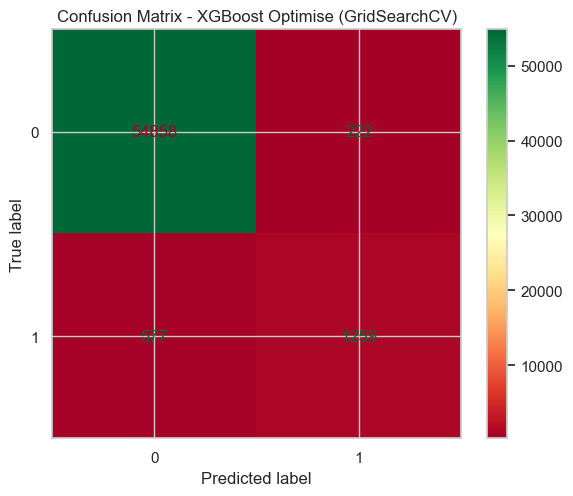


F1-Score (classe 1) : 0.7591


In [13]:
# Grille de parametres pour XGBoost
param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2],
    "n_estimators": [100, 200],
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    scoring="f1",
    cv=3,
    verbose=1,
    n_jobs=-1,
)

grid_search.fit(X_train_scaled, y_train)

print(
    f"\nMeilleurs hyperparametres : "
    f"{grid_search.best_params_}"
)
print(
    f"Meilleur F1-Score (CV) : "
    f"{grid_search.best_score_:.4f}"
)

# Evaluation du meilleur modele sur le test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print(
    "\nClassification Report (XGBoost Optimise) :"
)
print(classification_report(y_test, y_pred_best))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best, ax=ax, cmap="RdYlGn"
)
ax.set_title(
    "Confusion Matrix - XGBoost Optimise (GridSearchCV)"
)
plt.tight_layout()
plt.show()

print(
    f"\nF1-Score (classe 1) : "
    f"{f1_score(y_test, y_pred_best):.4f}"
)

### 2.6 Comparaison des modeles (Cross-Validation)

Evaluation robuste de tous les modeles en cross-validation 3-fold pour comparer les performances.

In [14]:
# Cross-validation F1 pour chaque modele (cv=3)
models = {
    "Logistic Regression": model_lr,
    "Random Forest": model_rf,
    "XGBoost (Defaut)": model_xgb,
    "XGBoost (Optimise)": best_model,
}

results = []
for name, model in models.items():
    cv_scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=3, scoring="f1", n_jobs=-1,
    )
    test_f1 = f1_score(
        y_test, model.predict(X_test_scaled)
    )
    results.append({
        "Modele": name,
        "F1 CV (Mean)": round(cv_scores.mean(), 4),
        "F1 CV (Std)": round(cv_scores.std(), 4),
        "F1 Test": round(test_f1, 4),
    })

comparison_df = pd.DataFrame(results)
print("Comparaison des modeles :")
display(comparison_df)

Comparaison des modeles :


,Modele,F1 CV (Mean),F1 CV (Std),F1 Test
0,Logistic Regression,0.5111,0.0014,0.5118
1,Random Forest,0.5754,0.0053,0.5761
2,XGBoost (Defaut),0.7561,0.0074,0.7544
3,XGBoost (Optimise),0.7650,0.0069,0.7591


## 3. Feature Importance

Variables les plus déterminantes selon le meilleur modèle (XGBoost optimisé).

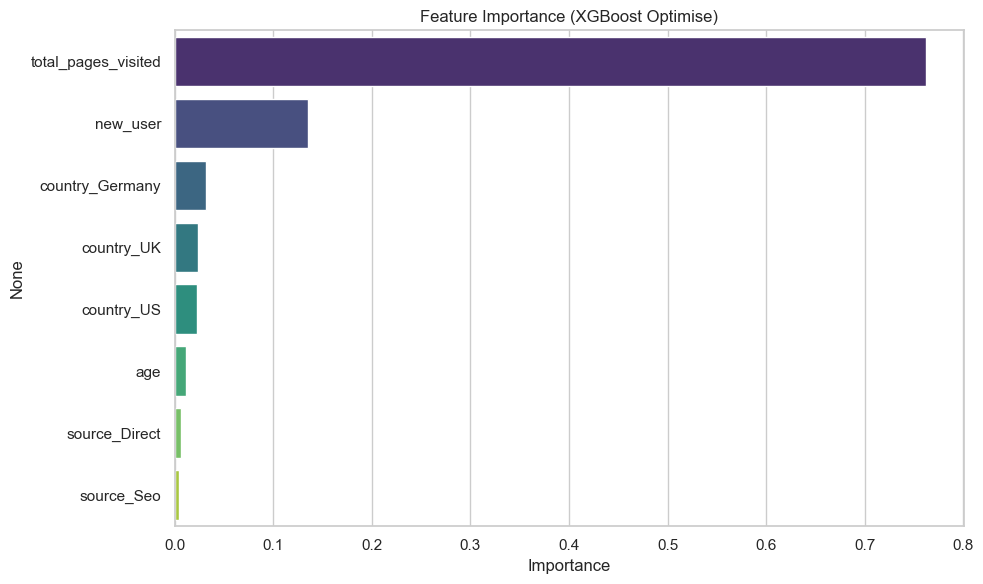

In [15]:
# Feature importance du meilleur modele
feature_names = X.columns
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(
    x=importances[indices],
    y=feature_names[indices],
    hue=feature_names[indices],
    legend=False,
    palette="viridis",
)
plt.title("Feature Importance (XGBoost Optimise)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 4. Prédiction sur les données de test (Submission)

Application du meilleur modèle sur `conversion_data_test.csv` avec le même preprocessing.

In [16]:
# Chargement des donnees de test
df_final = pd.read_csv(
    "../data/raw/conversion_data_test.csv"
)
print(f"Donnees finales chargees : {df_final.shape}")

# Preprocessing identique a l'entrainement
X_final = pd.get_dummies(df_final, drop_first=True)

# Alignement des colonnes avec le jeu d'entrainement
features_train = X.columns
X_final = X_final.reindex(
    columns=features_train, fill_value=0
)

# Normalisation avec le scaler deja entraine
X_final_scaled = scaler.transform(X_final)

# Predictions avec le meilleur modele
y_final_pred = best_model.predict(X_final_scaled)

# Generation du fichier de soumission
submission = pd.DataFrame({"converted": y_final_pred})
submission.to_csv(
    "../data/processed/submission.csv", index=False
)

print("Fichier 'submission.csv' genere.")
print("Distribution des predictions :")
print(pd.Series(y_final_pred).value_counts())

Donnees finales chargees : (31620, 5)
Fichier 'submission.csv' genere.
Distribution des predictions :
0    30779
1      841
Name: count, dtype: int64


## 5. Conclusion et recommandations

### Bilan des performances

| Modèle | F1 (CV) | F1 (Test) |
|--------|---------|-----------|
| Logistic Regression | 0.5111 | 0.5118 |
| Random Forest | 0.5754 | 0.5761 |
| XGBoost (défaut) | 0.7561 | 0.7544 |
| XGBoost (optimisé) | 0.7650 | 0.7591 |

### Leviers d'action

- `total_pages_visited` : prédicteur dominant. Au-delà de 12-15 pages, conversion quasi certaine. Inciter la navigation (liens internes, suggestions).
- `age` : les 18-30 ans convertissent mieux. Cibler les campagnes sur cette tranche.
- `new_user` : les utilisateurs récurrents convertissent mieux. Stratégie de retargeting pour faire revenir les visiteurs.
- `country` : disparités géographiques modérées. Adapter le contenu par région.

Le XGBoost optimisé (max_depth=7, lr=0.1) atteint F1=0.759, soit +48 % par rapport au baseline (LogReg F1=0.512). Les scores CV et test sont proches, pas d'overfitting.